## Libaries

In [207]:
import numpy as np
import pandas as pd
from pathlib import Path
import sys
import os

from statsmodels.stats.anova import AnovaRM
from scipy.stats import ttest_rel
from itertools import combinations
from statsmodels.stats.multitest import multipletests
from sklearn.metrics import confusion_matrix
from scipy.stats import friedmanchisquare
from scipy.stats import wilcoxon
import itertools

import matplotlib.pyplot as plt
import torch

current_dir = Path().resolve().parent.parent
sys.path.append(str(current_dir))

from src.utilities.load_and_visualize_data import DataAnalysis      # noqa: F402

In [193]:
# ----- Global style -----

plt.rcParams.update({
    # ---- Font ----
    "font.family": "serif",
    #"font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    #"mathtext.fontset": "stix",
    #"text.usetex": False,          # True for LaTeX rendering (optional)
    
    # ---- Font sizes (A4 layout, 10 pt doc) ----
    "font.size": 9,
    "axes.labelsize": 8,
    "axes.titlesize": 9,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    
    # ---- Line and color ----
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.5,
    "lines.markersize": 4,
    "axes.prop_cycle": plt.cycler(color=plt.cm.tab10.colors),

    # ---- Layout ----
    # Page size (247.000, 174.000) height, width
    # (5.5, 3.5) half-page 
    #"figure.figsize": (5.5, 3.5),  
    "figure.dpi": 400,
    "savefig.transparent": True,
    "savefig.bbox": "tight"
})

### Functions

In [204]:
def extract_model_specs(sherpa_log_folder = 'SingleNet_LSTM_EMG'):
    # Extract file
    sherpa_info_path = Path().resolve() / f"loggings/subject_independent/{sherpa_log_folder}/all_subjects/SHERPA_results.pt"
    if not os.path.exists(sherpa_info_path):
        raise FileExistsError(sherpa_info_path)
    
    data = torch.load(sherpa_info_path, weights_only=False)

    
    best_vloss = min(
        data["trials"],
        key=lambda x: np.mean(x["validation_loss"])
    )
    
    best_tacc = max(
        data['trials'],
        key = lambda x: x['test_accuracy']
    )

    # cm = confusion_matrix(best_vloss['labels'], best_vloss['predictions'])
    # print('Network : ', sherpa_log_folder)
    # print(cm)

    bv_summary_vloss = best_vloss['validation_loss']
    bv_summary_acc = best_vloss['test_accuracy']

    ba_summary_vloss = best_tacc['validation_loss']
    ba_summary_acc = best_tacc['test_accuracy']

    return bv_summary_vloss, ba_summary_vloss, bv_summary_acc, ba_summary_acc

## Data to analyse

In [319]:
#=====================================#
# Subject-dependent EEG across models #
#=====================================#
subj_EEG_acc = {
    
"LSTM": [30.56, 33.33, 40.74, 33.33, 29.63, 34.85, 41.33, 64.20, 33.33, 33.33, 33.33, 33.33, 33.33, 35.90, 33.33, 30.77, 39.13],    

"CNN+LSTM": [70.83, 64.29, 61.73, 33.33, 35.80, 33.33, 45.33, 77.78, 33.33, 49.38, 52.38, 50.00, 46.15, 37.18, 26.39, 37.18, 47.83],

"CNN+LSTM+Attention": [77.78, 63.10, 62.96, 53.33, 50.62, 50.00, 58.67, 80.25, 44.87, 60.49, 57.14, 56.41, 50.00, 58.97, 45.83, 43.59, 50.72]}

print(np.mean(subj_EEG_acc["LSTM"]), np.std(subj_EEG_acc["LSTM"]))
print(np.mean(subj_EEG_acc["CNN+LSTM"]), np.std(subj_EEG_acc["CNN+LSTM"]))
print(np.mean(subj_EEG_acc["CNN+LSTM+Attention"]), np.std(subj_EEG_acc["CNN+LSTM+Attention"]))

36.10294117647058 7.714083197942261
47.190588235294115 14.104795792916025
56.748823529411766 10.019372929980928


## Subject-dependent across models for EEG

### Load data and statistics

In [320]:
accuracies = subj_EEG_acc
models = list(accuracies.keys())

# Compare models within each subject
print('#-------------Compare models within each subject-------------#\n')
stat, p = friedmanchisquare(
    accuracies['LSTM'],
    accuracies['CNN+LSTM'],
    accuracies['CNN+LSTM+Attention']
)

print(accuracies['CNN+LSTM'])
print(accuracies['CNN+LSTM+Attention'])

print(f"Friedman test: stat={stat:.4f}, p={p:.4f}")


print('\n#-------------Corresponding wilcoxon-------------#')
pairs = list(itertools.combinations(range(len(models)), 2))

for i, j in pairs:
    i_id = models[i]
    j_id = models[j]
    stat, p = wilcoxon(accuracies[i_id], accuracies[j_id])
    print(f"Model {i_id} vs {j_id}: p={p:.4f}")

#-------------Compare models within each subject-------------#

[70.83, 64.29, 61.73, 33.33, 35.8, 33.33, 45.33, 77.78, 33.33, 49.38, 52.38, 50.0, 46.15, 37.18, 26.39, 37.18, 47.83]
[77.78, 63.1, 62.96, 53.33, 50.62, 50.0, 58.67, 80.25, 44.87, 60.49, 57.14, 56.41, 50.0, 58.97, 45.83, 43.59, 50.72]
Friedman test: stat=27.6364, p=0.0000

#-------------Corresponding wilcoxon-------------#
Model LSTM vs CNN+LSTM: p=0.0031
Model LSTM vs CNN+LSTM+Attention: p=0.0000
Model CNN+LSTM vs CNN+LSTM+Attention: p=0.0000


c:\Users\Bruger\Documents\hybrid_bci\.venv\Lib\site-packages\scipy\stats\_morestats.py:4088: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "


In [314]:
'''Repeated measure anova
#======================#
# Convert to dataframe #
#======================#
models = list(subj_EEG_acc.keys())
data = np.array([subj_EEG_acc[m]['EEG'] for m in models]).T  # shape: (subjects, models)

df = pd.DataFrame(data, columns=models)
df["subject"] = range(len(df))

# Long format (required for ANOVA)
df_long = df.melt(id_vars=["subject"], var_name="model", value_name="accuracy")

#==========#
# RM-ANOVA #
#==========#
anova = AnovaRM(df_long, depvar="accuracy", subject="subject", within=["model"])
res = anova.fit()

print("\n=== RM-ANOVA ===")
print(res)

#=========================#
# Post-hoc paired t-tests #
#=========================#
print("\n=== Post-hoc (paired t-tests, Holm corrected) ===")

p_vals = []
pairs = []

for m1, m2 in combinations(models, 2):
    t_stat, p = ttest_rel(df[m1], df[m2])
    p_vals.append(p)                        # p-value between models
    pairs.append((m1, m2))                  # Model pair

reject, p_corrected, _, _ = multipletests(p_vals, method='holm')

for i, (m1, m2) in enumerate(pairs):
    print(f"{m1} vs {m2}: p={p_corrected[i]:.4f}, significant={reject[i]}")
'''


'Repeated measure anova\n#======================#\n# Convert to dataframe #\n#======================#\nmodels = list(subj_EEG_acc.keys())\ndata = np.array([subj_EEG_acc[m][\'EEG\'] for m in models]).T  # shape: (subjects, models)\n\ndf = pd.DataFrame(data, columns=models)\ndf["subject"] = range(len(df))\n\n# Long format (required for ANOVA)\ndf_long = df.melt(id_vars=["subject"], var_name="model", value_name="accuracy")\n\n#==========#\n# RM-ANOVA #\n#==========#\nanova = AnovaRM(df_long, depvar="accuracy", subject="subject", within=["model"])\nres = anova.fit()\n\nprint("\n=== RM-ANOVA ===")\nprint(res)\n\n#=========================#\n# Post-hoc paired t-tests #\n#=========================#\nprint("\n=== Post-hoc (paired t-tests, Holm corrected) ===")\n\np_vals = []\npairs = []\n\nfor m1, m2 in combinations(models, 2):\n    t_stat, p = ttest_rel(df[m1], df[m2])\n    p_vals.append(p)                        # p-value between models\n    pairs.append((m1, m2))                  # Model pa

#### Plot accuracies

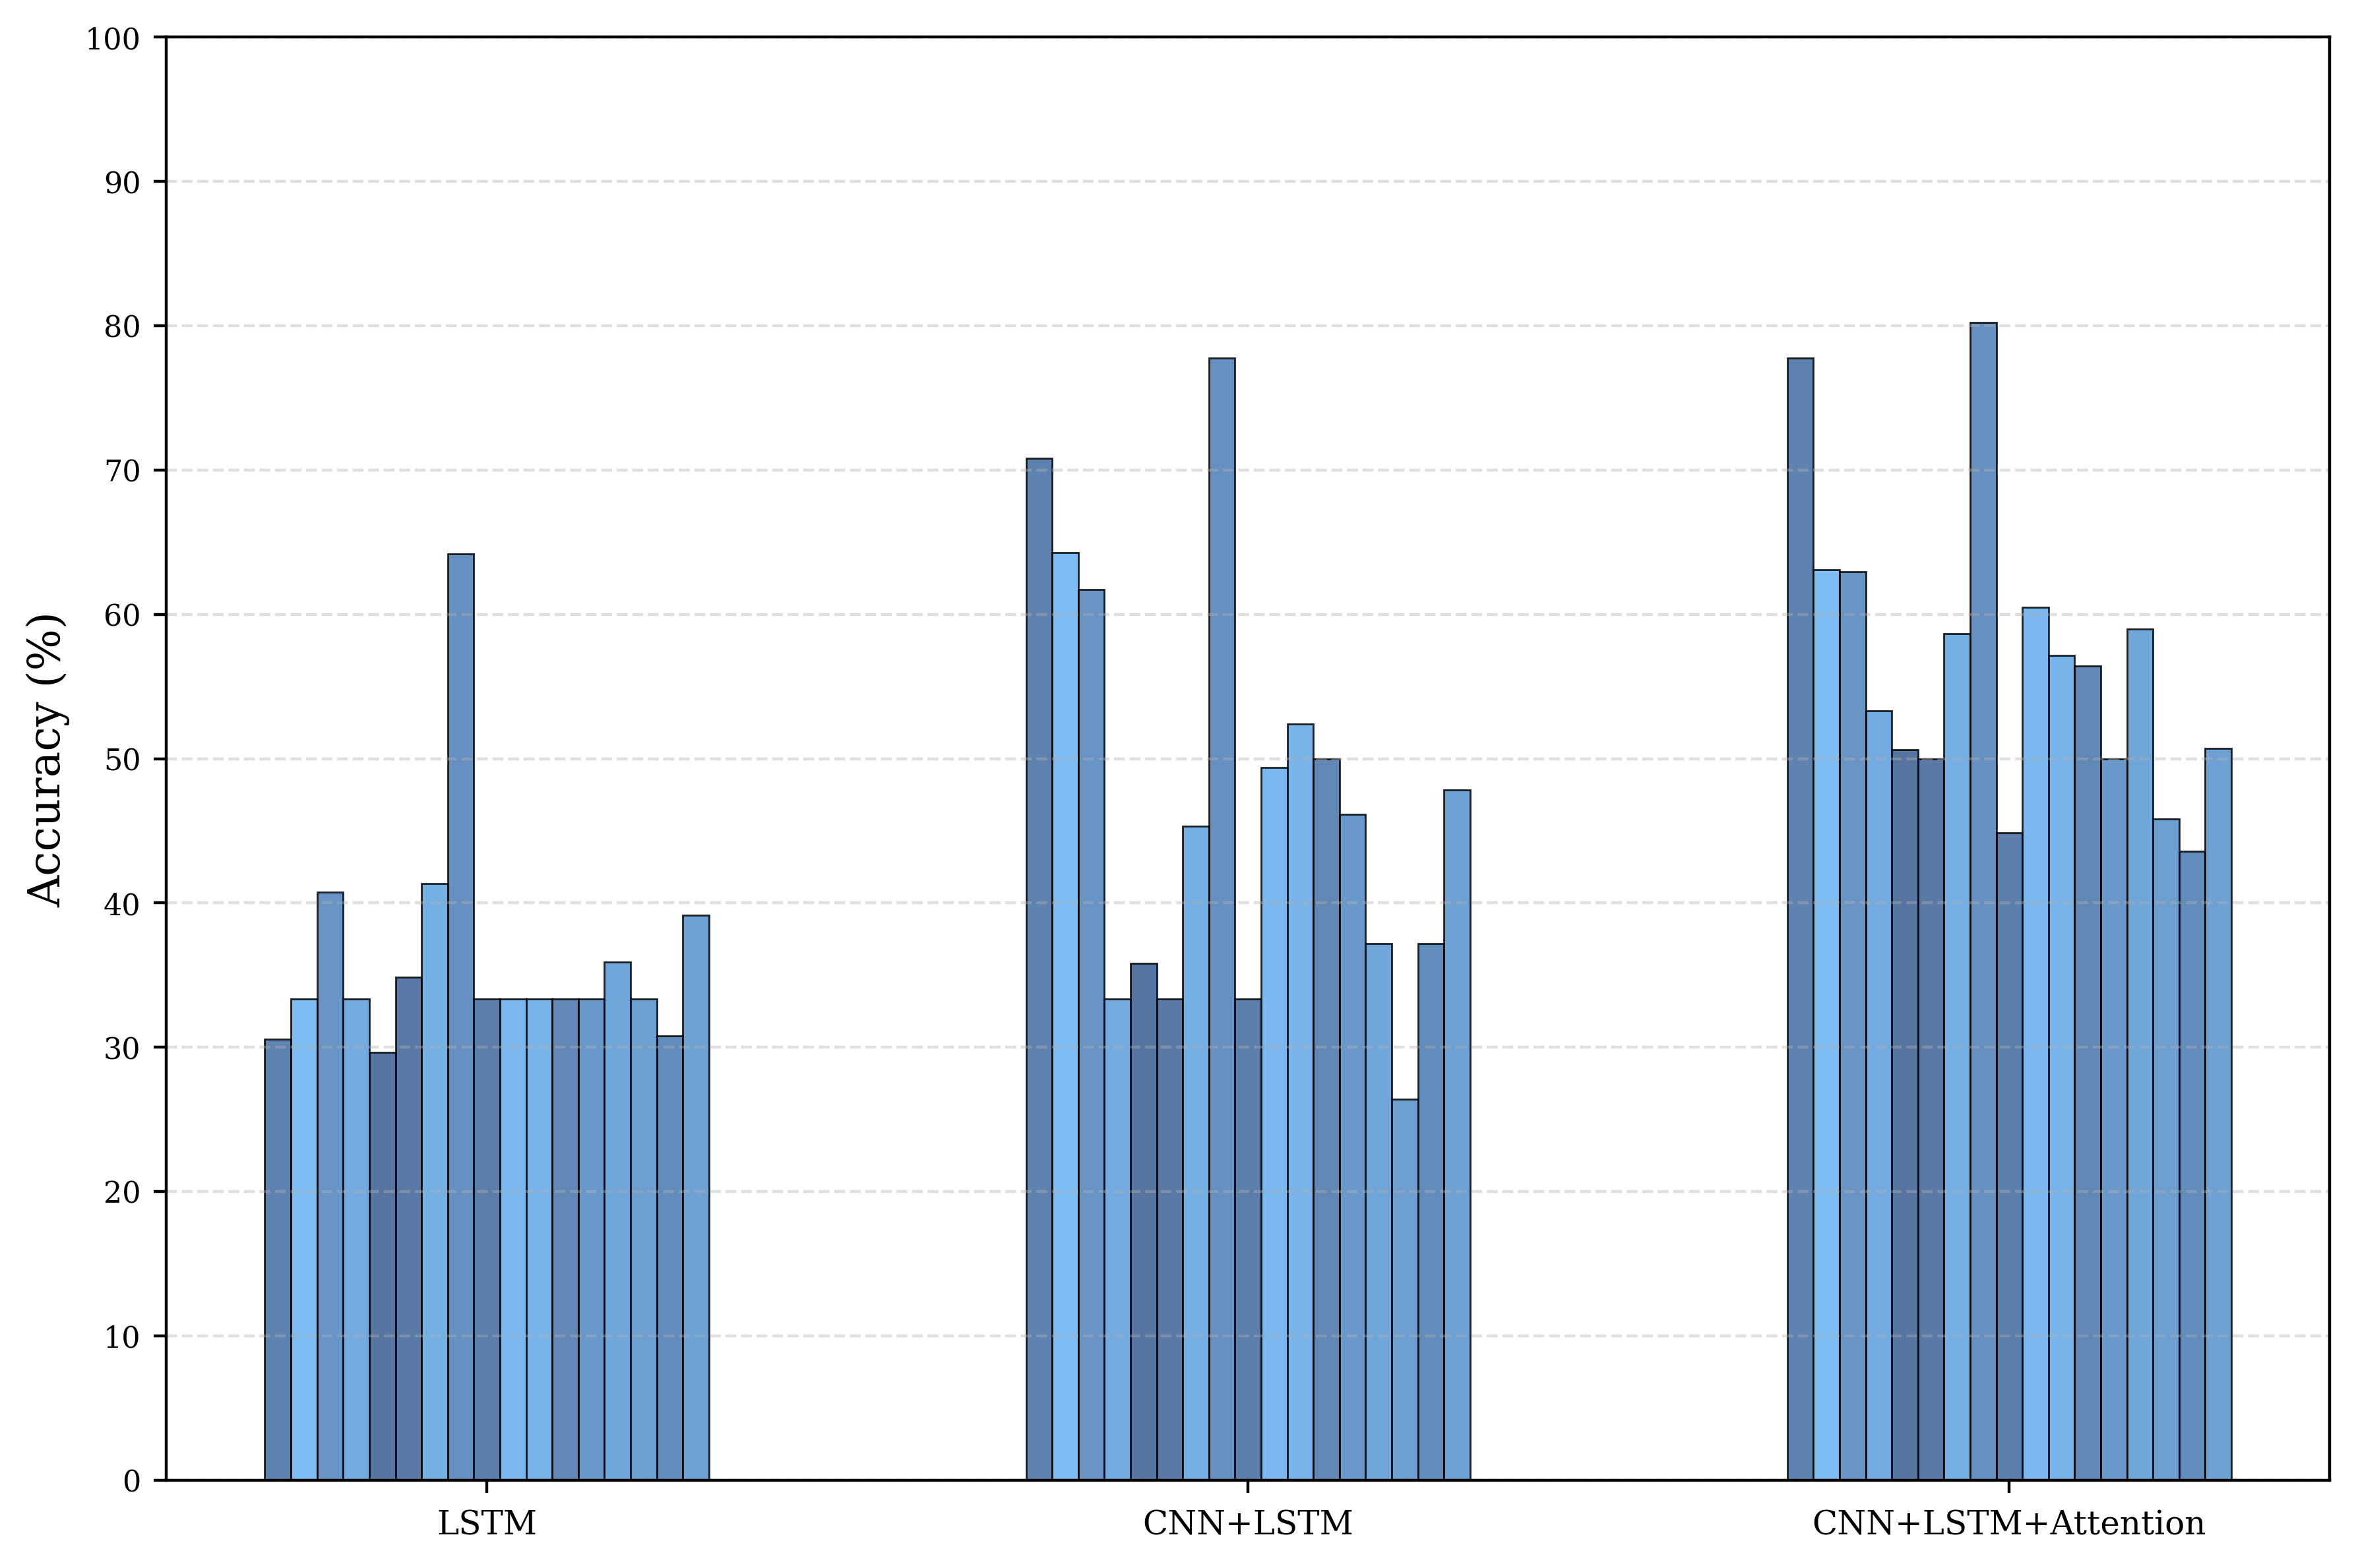

In [ ]:
import matplotlib.colors as mcolors

def _plot_subject_accuracy_hierarchical(subject_ids, accuracies, architectures):
    """
    Plot grouped bars with hierarchical x-axis:
    Architecture -> Modality

    Parameters
    ----------
    subject_ids : list
        Example: ['S1','S2','S3']

    accuracies : dict
        Dictionary structured like:

        {
            "LSTM": {
                "EEG": [...],
                "EMG": [...],
                "Fusion": [...]
            },
            "CNN+LSTM": {
                "EEG": [...],
                "EMG": [...],
                "Fusion": [...]
            },
            "CNN+LSTM+Attention": {
                "EEG": [...],
                "EMG": [...],
                "Fusion": [...]
            }
        }

    architectures : list
        Example: ['LSTM','CNN+LSTM','CNN+LSTM+Attention']
    """

    n_subjects = len(subject_ids)
    bar_width = 0.7 / n_subjects   # slightly tighter grouping

    x_positions = []
    arch_centers = []

    pos = 0
    for arch in architectures:
        x_positions.append(pos)
        arch_centers.append(pos)
        pos += 1.2   # spacing between architectures

    plt.figure(figsize=(9, 6))

    # # --- Color palette (same style as boxplot) ---
    # base_color = "#4C72B0"

    # # Create gradient shades for subjects (cleaner than random colors)
    # colors = plt.cm.Blues(np.linspace(0.4, 0.9, n_subjects))

    base_color = "#FF6469"

    # Create shades of the same base color
    cmap = mcolors.LinearSegmentedColormap.from_list(
        "custom_blues",
        ["#6BBCFF",  "#345385FF"]  # light → base → dark
    )
    # "#6BBCFF",  "#345385FF"
    # "#6BBCFF",  "#343C85FF"]  # light → base → dark
    colors = [cmap(i) for i in np.linspace(0.1, 0.9, n_subjects)]

    np.random.seed(40)
    np.random.shuffle(colors)
    

    # --- Plot bars ---
    for i, subject in enumerate(subject_ids):

        offset = (i - (n_subjects - 1)/2) * bar_width

        values = [
            accuracies[arch]['EEG'][i] for arch in architectures
        ]

        plt.bar(
            np.array(x_positions) + offset,
            values,
            bar_width,
            color=colors[i],
            edgecolor='black',
            linewidth=0.5,
            alpha=0.85
        )

    # --- Axes & labels ---
    plt.ylabel("Accuracy (%)", fontsize=12)
    plt.ylim([0, 100])
    plt.yticks(np.arange(0, 101, 10))

    # Remove default x tick labels (we replace them manually)
    plt.xticks(x_positions, [''] * len(x_positions))

    # --- Architecture labels (clean placement) ---
    for center, arch in zip(arch_centers, architectures):
        plt.text(center, -2, arch, ha='center', va='top')

    # --- Grid (same as boxplot) ---
    plt.grid(axis='y', linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.savefig('subject_dependent_accuracies.png', dpi=400, bbox_inches='tight')
    plt.show()

subject_list = [subj for subj in range(17)]
networks = ['LSTM','CNN+LSTM','CNN+LSTM+Attention']
_plot_subject_accuracy_hierarchical(subject_ids = subject_list, accuracies = subj_EEG_acc, architectures = networks)

## EEG band/regions analysis

### Load data -> compute PSD

In [315]:
#==============================#
# Load dataset and compute PSD #
#==============================#
base_dir = Path().resolve().parents[0] / 'experiment/data'
print(base_dir)
subjects = [f'subject_{nr}' for nr in range(17)]

PSD_ins = DataAnalysis(fs = 125, base_dir = base_dir)
data = PSD_ins.inspect_frequency_ranges(subjects = subjects)

#======================================================================#
# Convert to matrices (subjects × classes × regions × bands) for ANOVA #
#======================================================================#
n_subjects = len(data)
n_classes = len(data[0])
REGIONS = ['prefrontal', 'frontal', 'central', 'temporal', 'parietal']
BANDS = ['delta', 'theta', 'alpha', 'beta', 'gamma']

all_mats = []

for subj_data in data:
    subj_mats = []

    for feat_dict in subj_data:                      # Extract PSD features (per channel x per band) for Class1 and then class2
        
        # Convert dict → matrix (channels × bands)
        mat = np.zeros((len(REGIONS), len(BANDS)))

        for i, ch in enumerate(REGIONS):
            for j, band in enumerate(BANDS):
                mat[i, j] = np.mean(feat_dict[ch][band])
        
        subj_mats.append(mat)
    
    all_mats.append(subj_mats)

all_mats = np.array(all_mats)           # Shape: (Subj, class, region, band)

S, C, R, B = all_mats.shape

C:\Users\Bruger\Documents\hybrid_bci\src\experiment\data
C:\Users\Bruger\Documents\hybrid_bci\src\experiment\data\subject_0\EEG\flex_index_finger_2026-02-05 14-19-21.csv
C:\Users\Bruger\Documents\hybrid_bci\src\experiment\data\subject_0\EEG\flex_index_finger_2026-02-05 14-24-42.csv
C:\Users\Bruger\Documents\hybrid_bci\src\experiment\data\subject_0\EEG\flex_index_finger_2026-02-05 14-37-01.csv

=====FUNC : reject_routine =====

Final combined bad epoch indicies: [15 21 29 31 33 41 44 46 50 51 52 61 62 64 79 83]
Total bad epochs = 16 out of 90
C:\Users\Bruger\Documents\hybrid_bci\src\experiment\data\subject_0\EEG\flex_thumb_finger_2026-02-05 14-46-00.csv
C:\Users\Bruger\Documents\hybrid_bci\src\experiment\data\subject_0\EEG\flex_thumb_finger_2026-02-05 14-51-56.csv
C:\Users\Bruger\Documents\hybrid_bci\src\experiment\data\subject_0\EEG\flex_thumb_finger_2026-02-05 14-57-32.csv

=====FUNC : reject_routine =====

Final combined bad epoch indicies: [13 14 25 34 37 42 53 59 61 78 79 81 82 83]

### Statistics

In [317]:
#========================#
# Convert to long format #
#========================#
rows = []

for s in range(n_subjects):
    for c in range(n_classes):
        for r in range(len(REGIONS)):
            for b in range(len(BANDS)):
                rows.append({
                    "subject": s,
                    "class": f"class_{c}",
                    "region": f"{REGIONS[r]}",
                    "band": f"{BANDS[b]}",
                    "condition": f"C{c}_R{r}_B{b}",
                    "psd": all_mats[s, c, r, b]
                })

df_long = pd.DataFrame(rows)

anova = AnovaRM(
    df_long,
    depvar="psd",
    subject="subject",
    within=["condition"]
)

res = anova.fit()
print(res)


#=========================#
# Post-hoc paired t-tests #
#=========================#
print("\n=== Post-hoc (paired t-tests, Holm corrected) ===")
# [rest, contract, release] -> [class 0, class 1, class 2]

class_pairs = list(combinations(range(n_classes), 2))

for c1, c2 in class_pairs:
    print(f"\n=== Comparing class {c1} vs {c2} ===")

    p_vals = []
    labels = []

    for r in range(R):
        for b in range(B):

            x = all_mats[:, c1, r, b]
            y = all_mats[:, c2, r, b]

            _, p = ttest_rel(x, y)

            p_vals.append(p)
            labels.append((r, b))

    reject, p_corr, _, _ = multipletests(p_vals, method='holm')

    for i, (r, b) in enumerate(labels):
        if reject[i]:
            print(f"{REGIONS[r]}, {BANDS[b]}: p={p_corr[i]:.4f}")

#===========#
# Cohen's d #
#===========#
# print("\n=== Cohen's d for significant differences ===")
# cohend = PSD_ins.compute_multiclass_separability(data_classes = data, REGIONS = REGIONS, BANDS = BANDS)
# print(cohend)

                  Anova
          F Value  Num DF   Den DF  Pr > F
------------------------------------------
condition 20.2596 74.0000 1184.0000 0.0000


=== Post-hoc (paired t-tests, Holm corrected) ===

=== Comparing class 0 vs 1 ===
prefrontal, beta: p=0.0432
frontal, beta: p=0.0432
central, delta: p=0.0067
central, beta: p=0.0275

=== Comparing class 0 vs 2 ===
prefrontal, delta: p=0.0263
frontal, delta: p=0.0179
frontal, beta: p=0.0418
central, delta: p=0.0002
central, alpha: p=0.0475
central, beta: p=0.0084
temporal, delta: p=0.0047

=== Comparing class 1 vs 2 ===
prefrontal, alpha: p=0.0474
temporal, delta: p=0.0481
temporal, alpha: p=0.0481


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import shapiro

data = subj_EEG_acc['CNN+LSTM']['EEG']  # example

plt.figure()
sns.histplot(data, kde=True)

plt.title("Histogram + KDE")
plt.show()

stats.probplot(data, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

stat, p = shapiro(data)

print(f"Shapiro-Wilk: p={p:.4f}")

## Subject-independent across models for same modality

### Load data

In [210]:
sherpa_folders = ['SingleNet_LSTM_EMG', 'SingleNet_CNN+LSTM_EMG', 'SingleNet_CNN+LSTM+ATTENTION_EMG']
models_ids = ['model1', 'model2', 'model3']

bv_summary_vloss = {}
ba_summary_vloss = {}
bv_summary_acc = {}
ba_summary_acc = {}

for folder, model_id in zip(sherpa_folders, models_ids):
    bv_loss, ba_loss, bv_acc, ba_acc = extract_model_specs(sherpa_log_folder = folder)
    
    bv_summary_vloss[model_id] = bv_loss
    ba_summary_vloss[model_id] = ba_loss
    bv_summary_acc[model_id] = bv_acc
    ba_summary_acc[model_id] = ba_acc

print('Test accuracies :', 
      bv_summary_acc,
      ba_summary_acc)

Test accuracies : {'model1': 97.80439121756487, 'model2': 99.40119760479043, 'model3': 99.40119760479043} {'model1': 99.20159680638723, 'model2': 100.0, 'model3': 99.8003992015968}


### Statistics

In [212]:
losses = bv_summary_vloss

stat, p = friedmanchisquare(
    losses['model1'],
    losses['model2'],
    losses['model3']
)

print(f"Friedman test: stat={stat:.4f}, p={p:.4f}")

pairs = list(itertools.combinations(range(len(models_ids)), 2))

for i, j in pairs:
    i_id = models_ids[i]
    j_id = models_ids[j]
    stat, p = wilcoxon(losses[i_id], losses[j_id])
    print(f"Model {i_id} vs {j_id}: p={p:.4f}")

Friedman test: stat=12.2500, p=0.0022
Model model1 vs model2: p=0.0078
Model model1 vs model3: p=0.0078
Model model2 vs model3: p=0.3828


### Plot boxplot

C:\Users\Bruger\AppData\Local\Temp\ipykernel_19000\1697980627.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


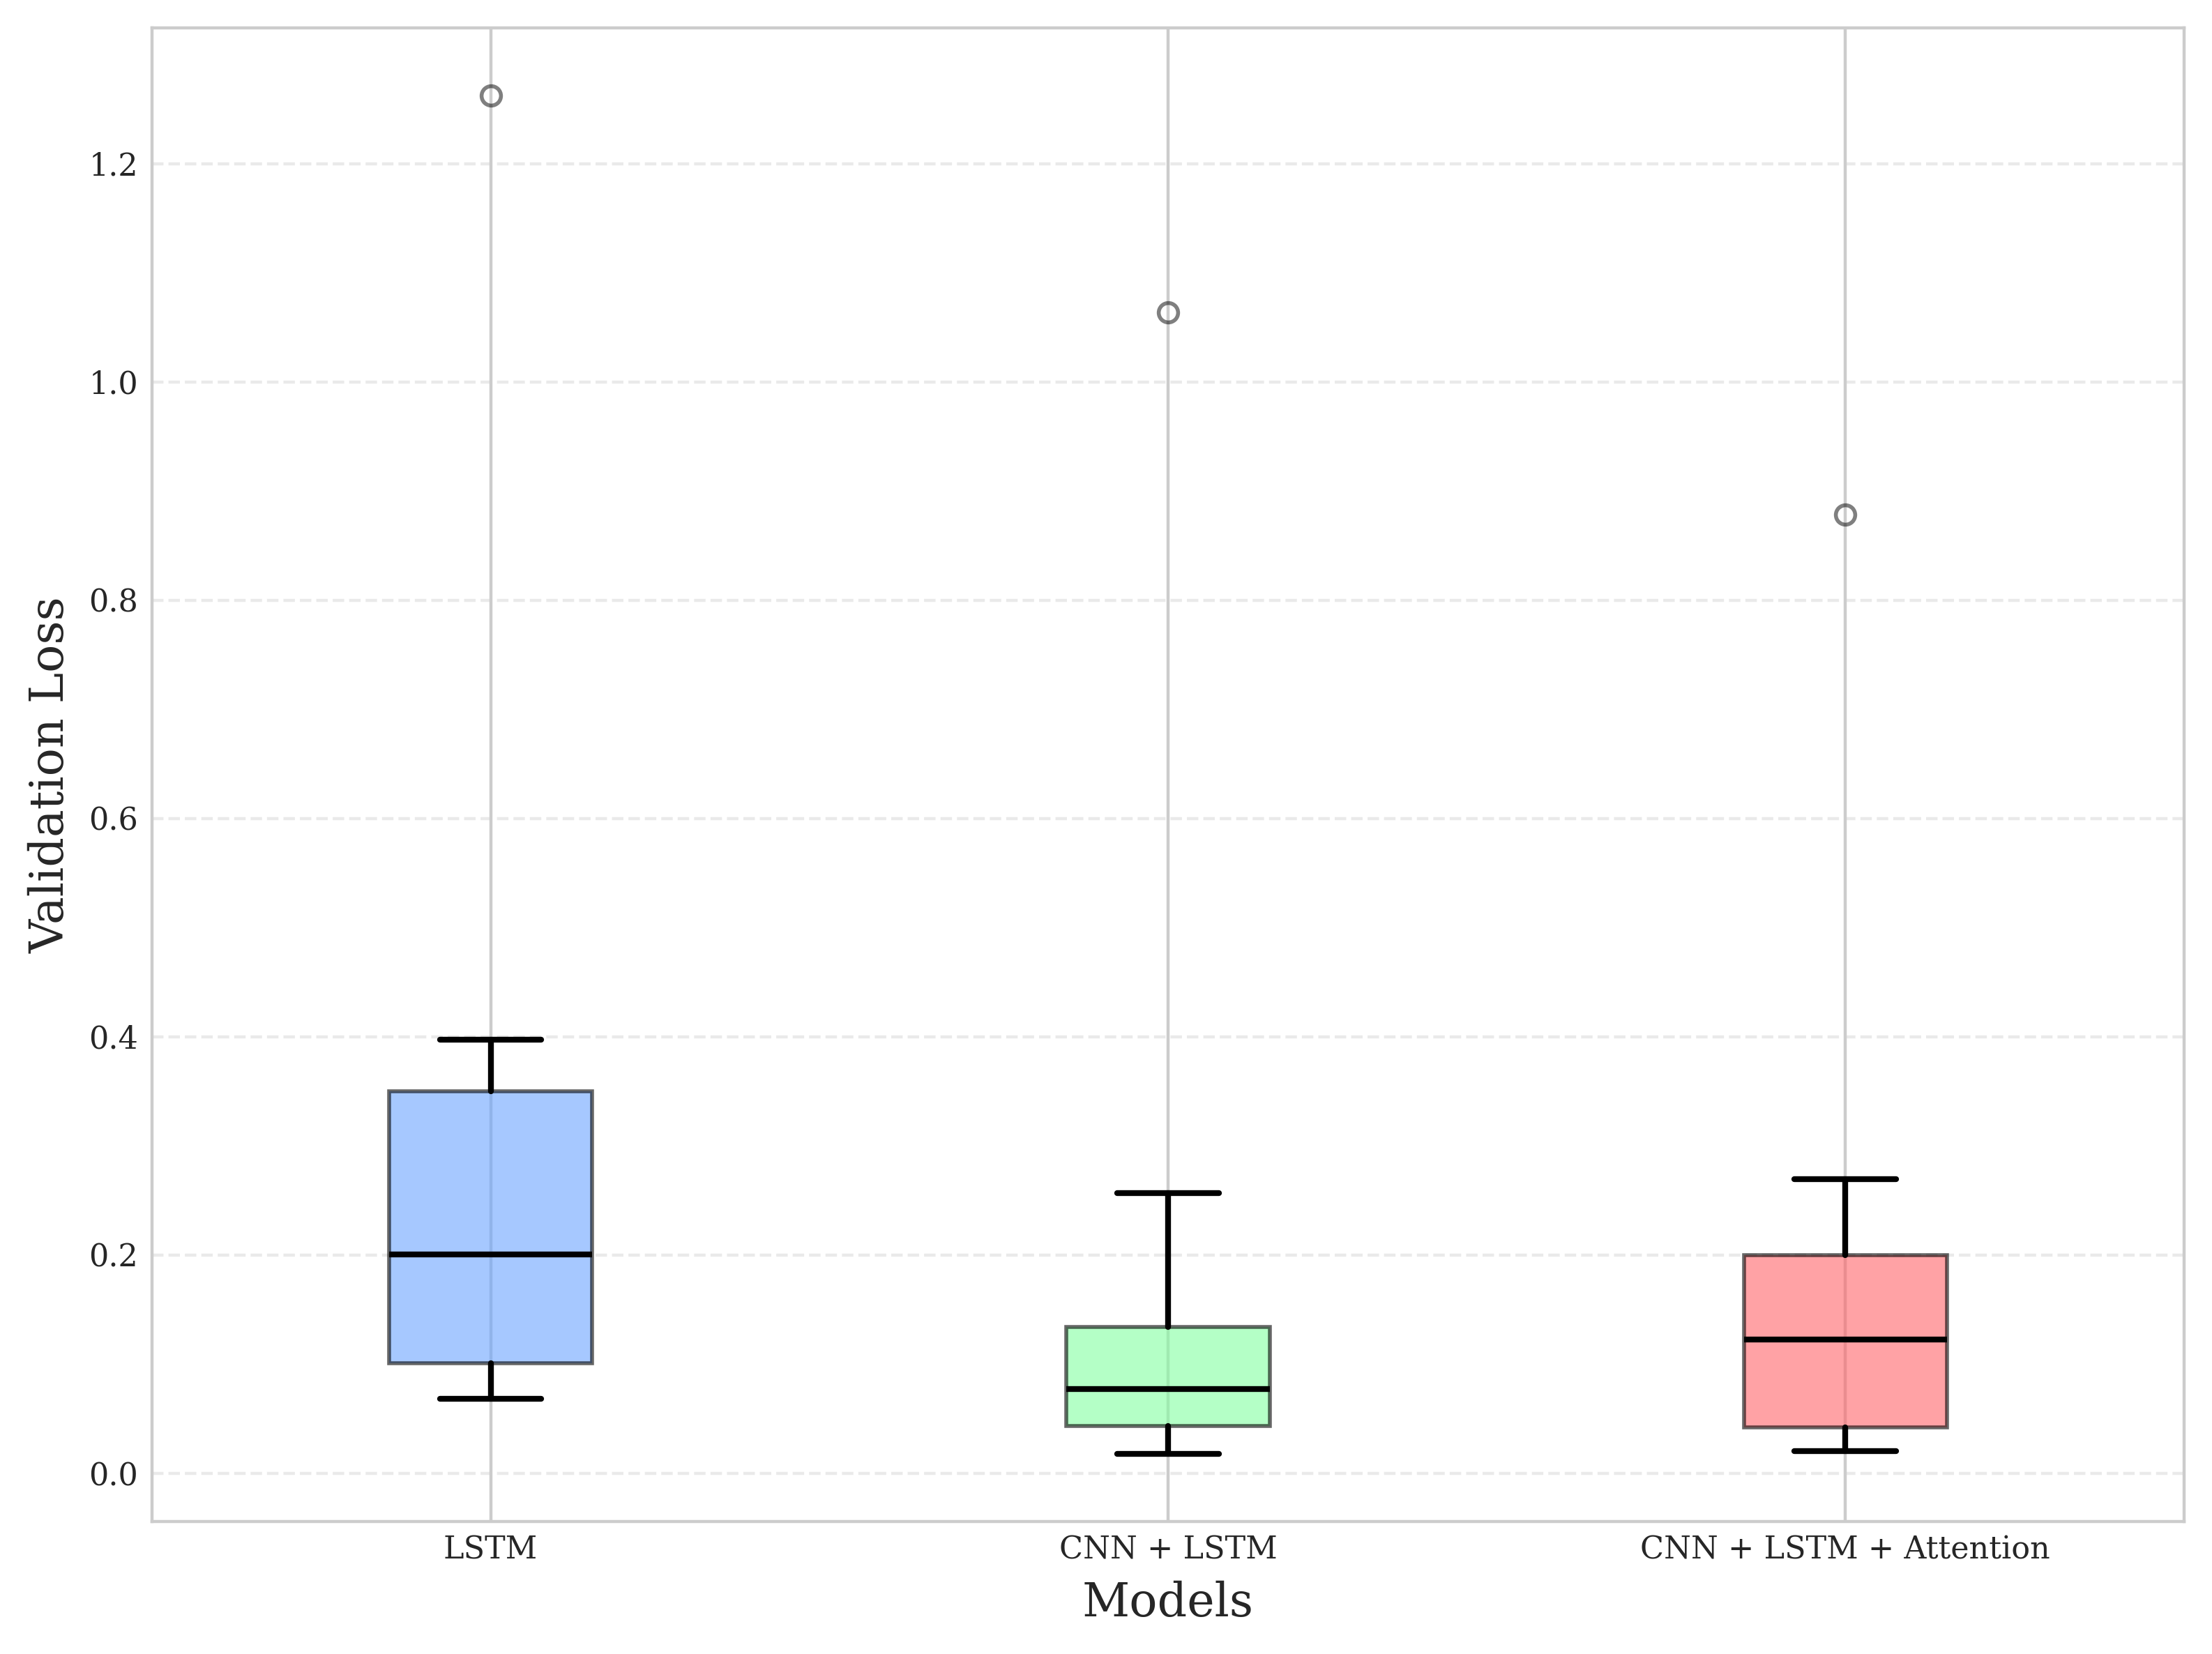

In [111]:
select_data = bv_summary_vloss

plt.figure(figsize=(8, 6))

data_to_plot = [select_data[m] for m in models_ids]

networks = ['LSTM', 'CNN + LSTM', 'CNN + LSTM + Attention']

# Create boxplot
box = plt.boxplot(
    data_to_plot,
    labels=networks,
    patch_artist=True,
    showmeans=False,
    medianprops=dict(color = 'black', linewidth=1.5),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    flierprops=dict(marker='o', markersize=5, alpha=0.5),
)

# Soft, professional colors
colors = ["#6BA4FF", "#83FFA0", "#FF6469"]

for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

# Add individual fold points (VERY important for transparency)
# for i, model in enumerate(models_ids):
#     y = select_data[model]
#     x = np.full(len(y), i + 1)  # all points exactly at the center
#     plt.scatter(x, y, alpha=0.7, s=30)

# Grid (subtle)
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Labels
plt.xlabel("Models", fontsize=12)
plt.ylabel("Validation Loss", fontsize=12)
# plt.title("Validation Loss Distribution Across Models", fontsize=14, weight='bold')

# Clean layout
plt.tight_layout()
plt.savefig('subject-independent vloss distribution of EMG.png')
plt.show()

## Subject-independent across models and modality

In [246]:
#=======================================#
# Load data for each model and modality #
#=======================================#
sherpa_folders = ['SingleNet_LSTM_', 'SingleNet_CNN+LSTM_', 'SingleNet_CNN+LSTM+ATTENTION_']

modality_ids = ['EEG', 'EMG']
models_ids = ['model1', 'model2', 'model3']


bv_summary_vloss = {}
ba_summary_vloss = {}
bv_summary_acc = {}
ba_summary_acc = {}

# Models
    # modalities

for folder, model_id in zip(sherpa_folders, models_ids):
    bv_summary_vloss[model_id] = {}
    ba_summary_vloss[model_id] = {}
    bv_summary_acc[model_id] = {}
    ba_summary_acc[model_id] = {}

    for mod in modality_ids:
        model = folder + mod
        print(model)
        bv_loss, ba_loss, bv_acc, ba_acc = extract_model_specs(sherpa_log_folder = model)
        
        bv_summary_vloss[model_id][mod] = bv_loss
        ba_summary_vloss[model_id][mod] = ba_loss
        bv_summary_acc[model_id][mod] = bv_acc
        ba_summary_acc[model_id][mod] = ba_acc

SingleNet_LSTM_EEG
SingleNet_LSTM_EMG
SingleNet_CNN+LSTM_EEG
SingleNet_CNN+LSTM_EMG
SingleNet_CNN+LSTM+ATTENTION_EEG
SingleNet_CNN+LSTM+ATTENTION_EMG


### Statistics

In [271]:
losses = bv_summary_vloss

# Compare models within each modality
print('#-------------Compare models within each modality-------------#\n')
for modality in modality_ids:
    stat, p = friedmanchisquare(
        losses[models_ids[0]][modality],
        losses[models_ids[1]][modality],
        losses[models_ids[2]][modality]
    )
    print(f"Modality {modality}: p={p:.4f}, stat={stat:.4f}")

print('\n#-------------Corresponding wilcoxon-------------#')
for modality in range(len(modality_ids)):
    print(f"\nPost-hoc for modality {modality_ids[modality]}")
    
    for i, j in itertools.combinations(range(len(models_ids)), 2):
        i_id = models_ids[i]
        j_id = models_ids[j]

        stat, p = wilcoxon(
            losses[i_id][modality_ids[modality]],
            losses[j_id][modality_ids[modality]]
        )
        print(f"Model {i} vs {j}: p={p:.4f}, stat: {stat:.8f}")

print('\n#-------------Compare modalities within each model-------------#\n')
# Compare modalities within each model - Need of 3 modalities
# for model in models_ids:
#     stat, p = friedmanchisquare(
#         losses[model][modality_ids[0]],
#         losses[model][modality_ids[1]],
#         losses[model][modality_ids[2]]
#     )
#     print(f"Model {model}: p={p:.4f}")

for model in models_ids:
    stat, p = wilcoxon(
        losses[model][modality_ids[0]],
        losses[model][modality_ids[1]]
    )
    print(f"Model {model}: p={p:.4f}, stat={stat:.4f}")

#-------------Compare models within each modality-------------#

Modality EEG: p=0.0022, stat=12.2500
Modality EMG: p=0.0022, stat=12.2500

#-------------Corresponding wilcoxon-------------#

Post-hoc for modality EEG
Model 0 vs 1: p=0.0078, stat: 0.00000000
Model 0 vs 2: p=0.0078, stat: 0.00000000
Model 1 vs 2: p=0.7422, stat: 15.00000000

Post-hoc for modality EMG
Model 0 vs 1: p=0.0078, stat: 0.00000000
Model 0 vs 2: p=0.0078, stat: 0.00000000
Model 1 vs 2: p=0.3828, stat: 11.00000000

#-------------Compare modalities within each model-------------#

Model model1: p=0.0156, stat=1.0000
Model model2: p=0.0156, stat=1.0000
Model model3: p=0.0078, stat=0.0000


### Plot Boxplot

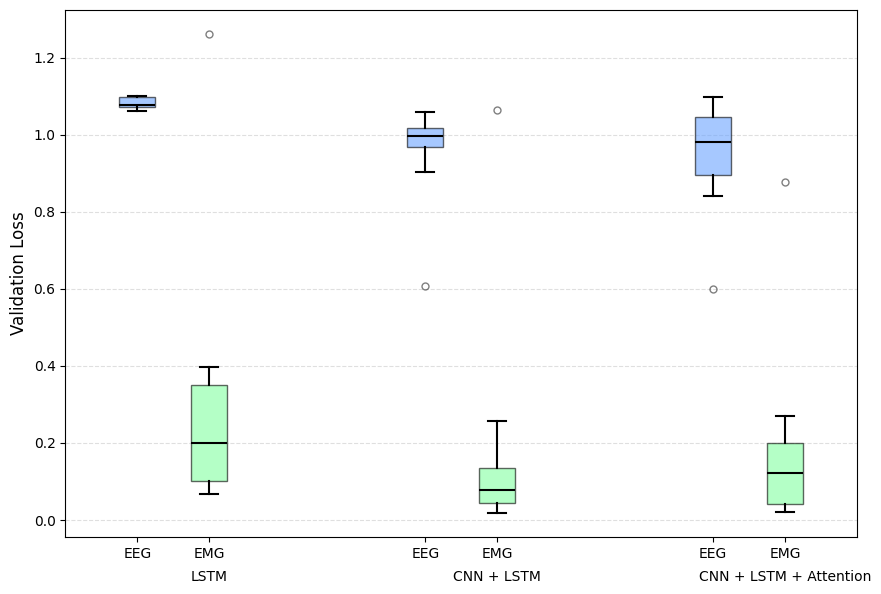

In [269]:
select_data = bv_summary_vloss

networks = ['LSTM', 'CNN + LSTM', 'CNN + LSTM + Attention']
models = ['model1', 'model2', 'model3']
modalities = ['EEG', 'EMG']

plt.figure(figsize=(9, 6))

positions = []
data_to_plot = []
colors = []

# --- Layout parameters ---
group_spacing = 1.0
box_spacing = 0.5

pos = 0
xticks = []
xtick_labels = []

# Color per modality (consistent across models)
modality_colors = {
    'EEG': "#6BA4FF",
    'EMG': "#83FFA0",
    'Fusion': "#FF6469"
}

# --- Build positions + data ---
for model in models:
    start = pos
    
    for mod, net in zip(modalities, networks):
        positions.append(pos)
        data_to_plot.append(select_data[model][mod])
        colors.append(modality_colors[mod])
        
        xtick_labels.append(mod)
        pos += box_spacing
    
    center = start + box_spacing
    xticks.append(center)
    
    pos += group_spacing

# --- Plot ---
box = plt.boxplot(
    data_to_plot,
    positions=positions,
    widths=0.25,
    patch_artist=True,
    medianprops=dict(color='black', linewidth=1.5),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    flierprops=dict(marker='o', markersize=5, alpha=0.5)
)

# --- Apply colors ---
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

# --- Grid ---
plt.grid(axis='y', linestyle='--', alpha=0.4)

# --- X ticks (modalities) ---
plt.xticks(positions, xtick_labels)

# --- Model labels underneath ---
for center, model in zip(xticks, networks):
    plt.text(center, -0.13, model, ha='center', va='top')

# --- Labels ---
plt.ylabel("Validation Loss", fontsize=12)
plt.xlabel("")

plt.tight_layout()
# plt.savefig('grouped_boxplot_modalities.png', dpi=400, bbox_inches='tight')
plt.show()